In [1]:
!apt-get install -y libzbar0
!pip install pyzbar opencv-python

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-droid-fallback fonts-noto-mono fonts-urw-base35 ghostscript gsfonts
  imagemagick-6-common libdjvulibre-text libdjvulibre21 libfftw3-double3
  libgs9 libgs9-common libidn12 libijs-0.35 libilmbase25 libjbig2dec0
  libjxr-tools libjxr0 liblqr-1-0 libmagickcore-6.q16-6
  libmagickcore-6.q16-6-extra libmagickwand-6.q16-6 libopenexr25 libv4l-0
  libv4lconvert0 libwmflite-0.2-7 poppler-data
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf fonts-texgyre
  ghostscript-x libfftw3-bin libfftw3-dev inkscape poppler-utils
  fonts-japanese-mincho | fonts-ipafont-mincho fonts-japanese-gothic
  | fonts-ipafont-gothic fonts-arphic-ukai fonts-arphic-uming fonts-nanum
The following NEW packages will be installed:
  fonts-droid-fallback fonts-noto-mono fonts-urw-base35 ghostscript gsfonts
  imagemagick-6-common libdjvulibre-t

SCANNER CODE

In [2]:
import cv2
from pyzbar.pyzbar import decode
from google.colab.patches import cv2_imshow
from google.colab import files

In [3]:
def preprocess(image):
    image = cv2.resize(image, (800, 800))
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Light processing only (don't destroy barcode)
    gray = cv2.equalizeHist(gray)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    return image, gray

In [4]:
def scan_barcode(image, gray):
    results = []

    # Try both versions
    decoded_gray = decode(gray)
    decoded_img = decode(image)

    decoded_objects = decoded_gray + decoded_img

    seen = set()  # avoid duplicates

    for obj in decoded_objects:
        data = obj.data.decode("utf-8").strip()

        if data in seen:
            continue
        seen.add(data)

        points = [(p.x, p.y) for p in obj.polygon]

        results.append({
    "data": data,
    "type": obj.type,
    "points": [(p.x, p.y) for p in obj.polygon]
})

    return results

In [5]:
def draw_boxes(image, results):
    for res in results:
        pts = res["points"]

        for i in range(len(pts)):
            pt1 = pts[i]
            pt2 = pts[(i + 1) % len(pts)]
            cv2.line(image, pt1, pt2, (0, 255, 0), 2)

        x, y = pts[0]
        cv2.putText(image, res["data"], (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (0, 255, 0), 2)

    return image

Saving main.jpeg to main.jpeg
Detected: [{'data': '4005808890507', 'type': 'EAN13', 'points': [(292, 431), (292, 473), (296, 667), (401, 680), (499, 656), (499, 430), (398, 430)]}]


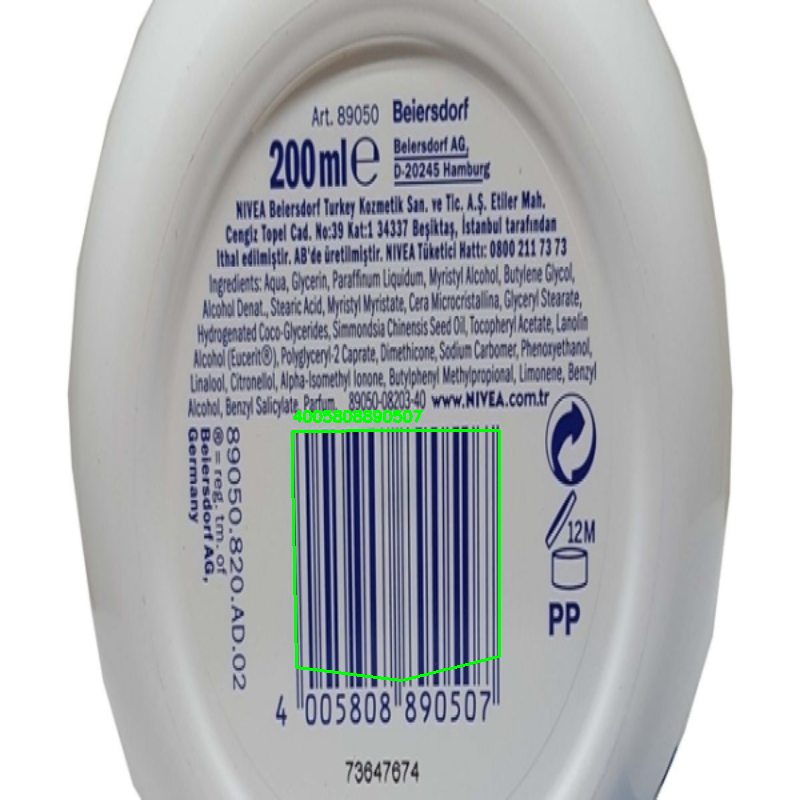

In [15]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path)

if image is None:
    print("Error loading image")
else:
    # Resize to speed up processing
    image = cv2.resize(image, (600, 600))

    img, gray = preprocess(image)

    results = scan_barcode(img, gray)

    print("Detected:", results)

    if results:
        img = draw_boxes(img, results)

    cv2_imshow(img)

Get Ingredients (Parallel APIs)

In [16]:
import aiohttp
import asyncio

In [17]:
async def fetch_openfoodfacts(session, barcode):
    url = f"https://world.openfoodfacts.org/api/v0/product/{barcode}.json"

    try:
        async with session.get(url, timeout=1.5) as resp:
            data = await resp.json()

            if data.get("status") == 1:
               product = data["product"]
            else:
               print("❌ No product data → OCR fallback next")
               product = None

               return {
                    "source": "openfoodfacts",
                    "name": product.get("product_name"),
                    "brand": product.get("brands"),
                    "ingredients": product.get("ingredients_text"),
                    "image": product.get("image_url")
                }

    except:
        return None

In [18]:
async def get_product_info(barcode):
    async with aiohttp.ClientSession() as session:

        tasks = [
            fetch_openfoodfacts(session, barcode),
            fetch_openbeauty(session, barcode)
        ]

        results = await asyncio.gather(*tasks)

        # Pick first valid result
        for r in results:
            if r:
                return r

    return {"error": "Product not found"}

In [19]:
async def fetch_openbeauty(session, barcode):
    url = f"https://world.openbeautyfacts.org/api/v0/product/{barcode}.json"

    try:
        async with session.get(url, timeout=1.5) as response:

            if response.status == 200:
                data = await response.json()

                if data.get("status") == 1:
                    product = data["product"]
                    return {
                        "source": "openbeautyfacts",
                        "name": product.get("product_name"),
                        "brand": product.get("brands"),
                        "ingredients": product.get("ingredients_text"),
                        "image": product.get("image_url")
                    }

    except:
        return None

    return None

❌ No product data → OCR fallback next

🍽 Product Info:
{'source': 'openbeautyfacts', 'name': 'Nivea soft', 'brand': 'Nivea', 'ingredients': None, 'image': 'https://images.openbeautyfacts.org/images/products/400/580/889/0507/front_de.14.400.jpg'}


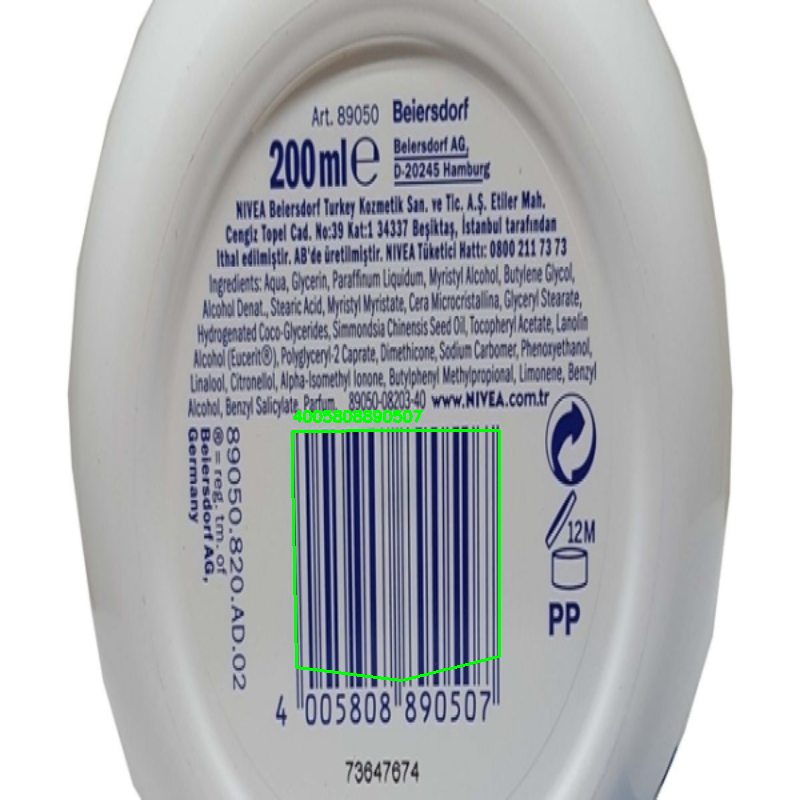

In [20]:
if not results:
    print("❌ No barcode detected → OCR fallback next")
    barcode = None
else:
    barcode = results[0]["data"]

    # Fix: Directly await the async function instead of using asyncio.run()

    product_info = await get_product_info(barcode)
    print("\n🍽 Product Info:")
    print(product_info)

    img = draw_boxes(img, results)

cv2_imshow(img)

OCR fallback

In [13]:
!pip install easyocr opencv-python rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 120.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 16.4 MB/s eta 0:00:00


In [21]:
import re
import easyocr
from rapidfuzz import process

# =========================
# 1. OCR ENGINE
# =========================
reader = easyocr.Reader(['en'])


# =========================
# 2. DOMAIN KNOWLEDGE (INCI)
# =========================
KNOWN_INGREDIENTS = {
    "butylene glycol",
    "denatured alcohol",
    "stearic acid",
    "myristyl myristate",
    "cera microcristallina",
    "glyceryl stearate",
    "hydrogenated glycerides",
    "tocopherol",
    "sodium carbomer",
    "limonene",
    "citronellol",
    "benzyl alcohol",
    "benzyl salicylate",
    "parfum",
    "fragrance",
    "simondsia chinensis seed oil",
    "phenoxyethanol",
    "methyl ionone",
    "linalool",
    "water",
    "glycerin"
}


# =========================
# 3. OCR CLEANING
# =========================
def clean_ocr(text):
    text = text.lower()
    text = re.sub(r'ingredients[:\-]', ' ingredients ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-zA-Z,;\.\- ]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# =========================
# 4. EXTRACT INGREDIENT BLOCK
# =========================
def extract_block(text):
    match = re.search(r'ingredients[:\-](.*)', text)
    if match:
        return match.group(1)
    return text[int(len(text) * 0.4):]


# =========================
# 5. SMART SPLIT (FIXED)
# =========================
def smart_split(text):
    parts = re.split(r'[,\n;]', text)

    tokens = []
    for p in parts:
        p = p.strip()
        if len(p) > 2:
            tokens.append(p)

    return tokens


# =========================
# 6. PHRASE MAP (FIXED)
# =========================
PHRASE_MAP = {
    "ghcol": "glycol",
    "ghycendes": "glycerides",
    "foqehyceryi": "glyceryl",
    "frencryethanok": "phenoxyethanol",
    "methylctopional": "methyl ionone",
    "salicjlale": "benzyl salicylate",
    "hpdrogetated": "hydrogenated",
    "butylehenyl": "butylphenyl",
    "nd": "",
    "ttt": "",
    "comtr": "",
    "aucchot": ""
}


# =========================
# 7. PHRASE REPAIR (UPGRADED)
# =========================
def phrase_repair(tokens):
    fixed = []

    for phrase in tokens:
        phrase = phrase.lower()

        # apply corrections inside phrase
        for wrong, correct in PHRASE_MAP.items():
            phrase = phrase.replace(wrong, correct)

        # remove garbage tokens
        phrase = re.sub(r'\b(nd|ttt|comtr|aucchot)\b', '', phrase)

        phrase = re.sub(r'\s+', ' ', phrase).strip()

        if len(phrase) > 2:
            fixed.append(phrase)

    return fixed


# =========================
# 8. OPTIONAL MERGE (BOOST)
# =========================
def merge_fragments(tokens):
    merged = []
    buffer = ""

    for t in tokens:
        if len(t.split()) == 1:
            buffer += " " + t
        else:
            if buffer:
                merged.append(buffer.strip())
                buffer = ""
            merged.append(t)

    if buffer:
        merged.append(buffer.strip())

    return merged


# =========================
# 9. NORMALIZATION (PHRASE LEVEL)
# =========================
def normalize_phrase(phrase):
    match = process.extractOne(phrase, KNOWN_INGREDIENTS)

    if match and match[1] > 75:
        return match[0]

    return phrase


# =========================
# 10. FINAL PIPELINE
# =========================
def cosmetic_scanner(image_path):

    # OCR
    results = reader.readtext(image_path)
    raw_text = " ".join([r[1] for r in results])

    # CLEAN
    cleaned = clean_ocr(raw_text)
    block = extract_block(cleaned)

    # SPLIT (FIXED)
    tokens = smart_split(block)

    # REPAIR
    tokens = phrase_repair(tokens)

    # OPTIONAL BOOST
    tokens = merge_fragments(tokens)

    # FILTER LIGHT NOISE
    tokens = [t for t in tokens if len(t) > 3]

    # NORMALIZE + DEDUP
    final = []
    seen = set()

    for t in tokens:
        fixed = normalize_phrase(t)

        if fixed and fixed not in seen:
            seen.add(fixed)
            final.append(fixed)

    return final


# =========================
# 11. RUN (COLAB)
# =========================
img_path = image_path  # from previous cell

ingredients = cosmetic_scanner(img_path)

print("\n✨ FINAL CLEAN INGREDIENTS:\n")
for i in ingredients:
    print("-", i)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



✨ FINAL CLEAN INGREDIENTS:

- butylene glycol
- steanc
- myristyl myristate
- cera microcristallina
- simondsia chinensis seed oil
- glyceryl stearate
- sodium carbomer
- phenoxyethanol
- methyl ionone
- limonene
- benzyl alcohol
- benzyl salicylate
- parfum
